# Day 10/60 — Database Sharding

## System Design Series

**Topic:** As data grows every day, your database gets more overloaded. It is time to scale the data tier. **Sharding** (also called Horizontal Scaling) separates a large database into smaller, independently managed parts called shards. Each shard shares the same schema, but holds a unique, non-overlapping subset of the data.

**What we cover:**
- Core sharding architecture: hash-based routing from app servers to shards
- Shard key selection and hash function routing mechanics
- Resharding challenge and consistent hashing as the solution
- Celebrity / hotspot key problem and four mitigation strategies
- Cross-shard JOIN problem and denormalisation workaround
- Sharding strategies: range, hash, directory, geo-based
- Architecture evolution and Day 10 scorecard

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_SHARD     = '#2980B9'   # blue   — shard / data node
C_HASH      = '#E67E22'   # amber  — hash function / router
C_HOT       = '#C44E52'   # red    — hotspot / overloaded shard
C_OK        = '#27AE60'   # green  — balanced / healthy
C_CELEBRITY = '#8E44AD'   # purple — celebrity / heavy-hitter key
C_DENORM    = '#2E86AB'   # teal   — denormalised data
C_GRAY      = '#F8F9FA'
C_ORANGE    = '#DD8452'
C_TEAL      = '#2E86AB'

print("Libraries loaded. Day 10 ready.")


Libraries loaded. Day 10 ready.


### What this does

Loads Matplotlib and NumPy with the Day 10 colour palette:

| Constant | Colour | Meaning |
|---|---|---|
| `C_SHARD` | Blue | Shard / data node |
| `C_HASH` | Amber | Hash function / shard router |
| `C_HOT` | Red | Hotspot / overloaded node |
| `C_OK` | Green | Balanced / healthy distribution |
| `C_CELEBRITY` | Purple | Celebrity / heavy-hitter key |
| `C_DENORM` | Teal | Denormalised data store |

The amber router sitting between blue app servers and blue shards is the central motif of this day.

## 2. Core Sharding Architecture

> "Sharding separates large databases into smaller, more easily managed parts called shards. Each shard shares the same schema, though the actual data on each shard is unique to the shard." — Day 10

**The problem with a single database at scale:**
- Table scans get slower as row count grows
- All writes go through a single primary — write bottleneck
- Vertical scaling (bigger server) has a hardware ceiling
- A single failure takes down the entire data tier

**Sharding solves this by splitting data horizontally:**
Each shard is an independent database server with its own CPU, RAM, and disk. The application uses a **shard router** to direct each query to the correct shard based on the shard key.

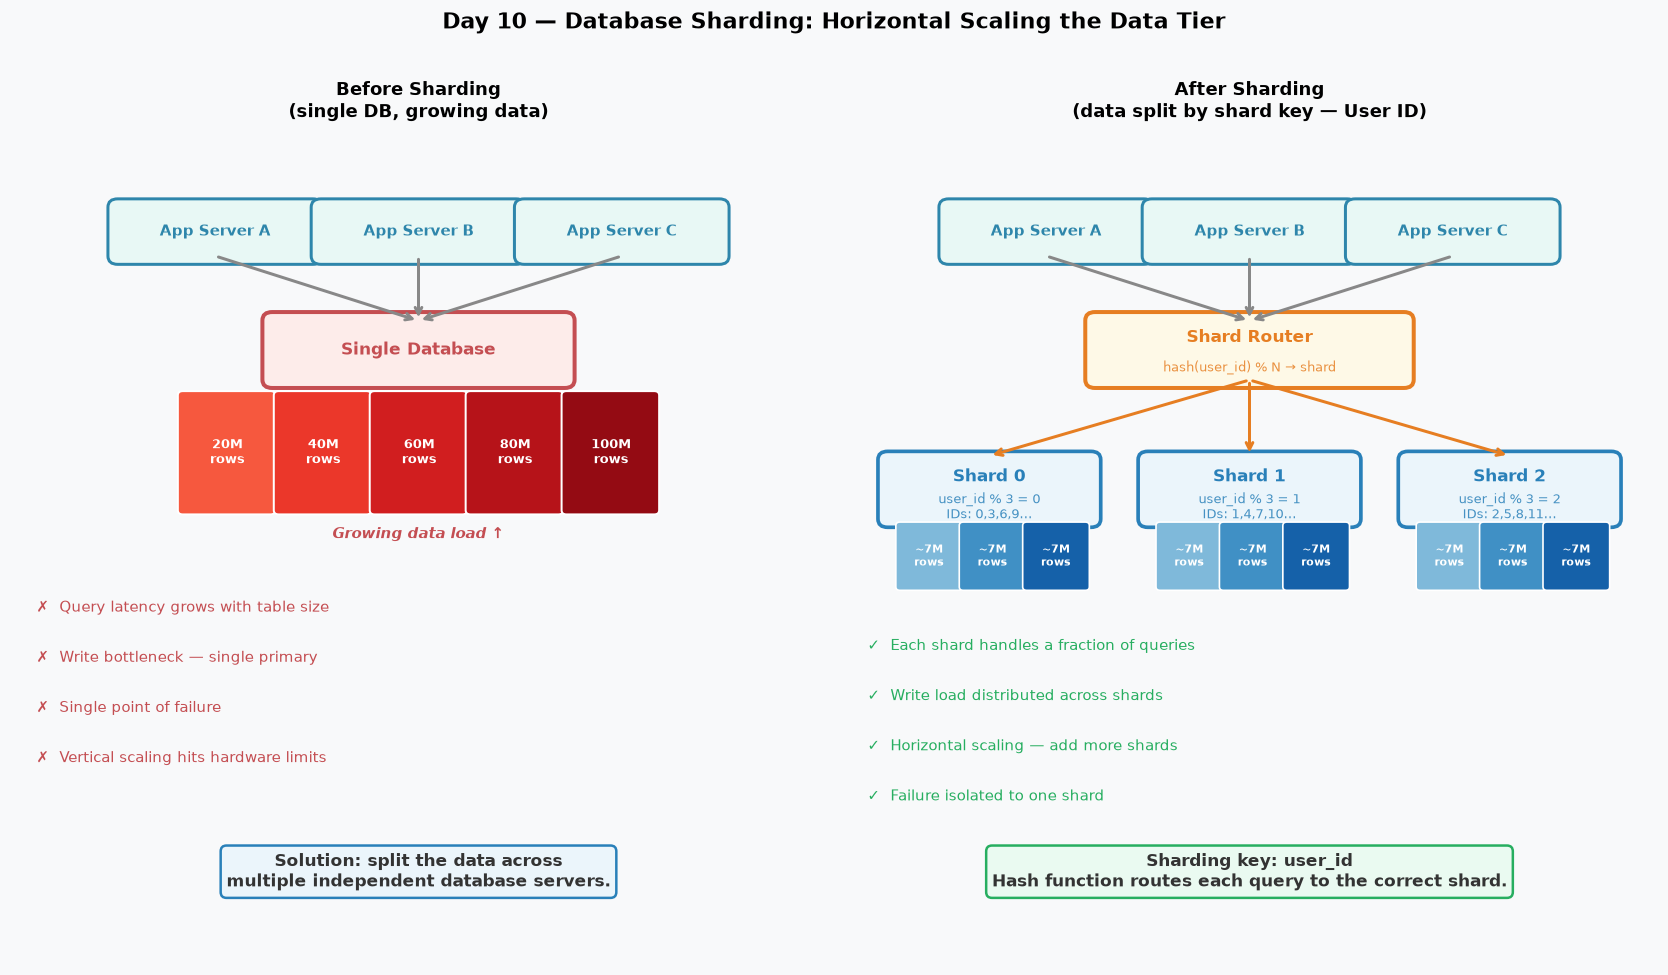

In [2]:
# Core sharding architecture: single DB → sharded DB cluster

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.25, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2
        ax.text(mx, my, label, ha='left', va='center', fontsize=8,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Left: single overloaded database ─────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Before Sharding\n(single DB, growing data)', fontsize=11, fontweight='bold')

# Application servers
for i, (xp, lbl) in enumerate([(2.5, 'App Server A'),
                                (5.0, 'App Server B'),
                                (7.5, 'App Server C')]):
    rbox(ax, xp, 10.5, 2.4, 0.7, lbl, C_TEAL, bg='#E8F8F5', fs=9)
    arr(ax, xp, 10.15, 5.0, 9.22, '', '#888')

# Single DB — shown overloaded
rbox(ax, 5.0, 8.8, 3.6, 0.85, 'Single Database', C_HOT,
     bg='#FDECEA', sub='', fs=10, lw=2.4)

# Data growing blocks
for i in range(5):
    shade = 0.55 + i * 0.09
    r = FancyBboxPatch((2.1 + i * 1.18, 6.5), 1.08, 1.65,
                       boxstyle='round,pad=0.06',
                       facecolor=plt.cm.Reds(shade), edgecolor='white', lw=1.2)
    ax.add_patch(r)
    ax.text(2.65 + i * 1.18, 7.33, f'{20*(i+1)}M\nrows', ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white')

ax.text(5.0, 6.1, 'Growing data load ↑', ha='center', fontsize=9,
        color=C_HOT, fontstyle='italic', fontweight='bold')

# Pain points
pain = [
    'Query latency grows with table size',
    'Write bottleneck — single primary',
    'Single point of failure',
    'Vertical scaling hits hardware limits',
]
for i, pt in enumerate(pain):
    ax.text(0.3, 5.1 - i * 0.72, f'✗  {pt}', ha='left', va='center',
            fontsize=9, color=C_HOT)

ax.text(5.0, 1.1,
        'Solution: split the data across\nmultiple independent database servers.',
        ha='center', fontsize=10, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EBF5FB',
                  edgecolor=C_SHARD, lw=1.5))

# ── Right: sharded cluster ────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('After Sharding\n(data split by shard key — User ID)', fontsize=11, fontweight='bold')

# App servers
for xp, lbl in [(2.5, 'App Server A'), (5.0, 'App Server B'), (7.5, 'App Server C')]:
    rbox(ax, xp, 10.5, 2.4, 0.7, lbl, C_TEAL, bg='#E8F8F5', fs=9)
    arr(ax, xp, 10.15, 5.0, 9.22, '', '#888')

# Hash router
rbox(ax, 5.0, 8.8, 3.8, 0.85, 'Shard Router', C_HASH,
     bg='#FEF9E7', sub='hash(user_id) % N → shard', fs=10, lw=2.4)

# Three shards
shard_data = [
    (1.8,  'Shard 0', 'user_id % 3 = 0\nIDs: 0,3,6,9…'),
    (5.0,  'Shard 1', 'user_id % 3 = 1\nIDs: 1,4,7,10…'),
    (8.2,  'Shard 2', 'user_id % 3 = 2\nIDs: 2,5,8,11…'),
]
for sx, slbl, ssub in shard_data:
    arr(ax, 5.0, 8.37, sx, 7.28, '', C_HASH)
    rbox(ax, sx, 6.8, 2.5, 0.85, slbl, C_SHARD,
         bg='#EBF5FB', sub=ssub, fs=10, lw=2.2)

# Data rows inside each shard
for i, sx in enumerate([1.8, 5.0, 8.2]):
    for j in range(3):
        shade = 0.45 + j * 0.18
        r = FancyBboxPatch((sx - 1.1 + j * 0.78, 5.4), 0.72, 0.88,
                           boxstyle='round,pad=0.05',
                           facecolor=plt.cm.Blues(shade), edgecolor='white', lw=1.0)
        ax.add_patch(r)
        ax.text(sx - 0.74 + j * 0.78, 5.84, f'~7M\nrows', ha='center', va='center',
                fontsize=6.5, fontweight='bold', color='white')

# Benefits
benefits = [
    'Each shard handles a fraction of queries',
    'Write load distributed across shards',
    'Horizontal scaling — add more shards',
    'Failure isolated to one shard',
]
for i, pt in enumerate(benefits):
    ax.text(0.3, 4.55 - i * 0.72, f'✓  {pt}', ha='left', va='center',
            fontsize=9, color=C_OK)

ax.text(5.0, 1.1,
        'Sharding key: user_id\n'
        'Hash function routes each query to the correct shard.',
        ha='center', fontsize=10, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAFAF1',
                  edgecolor=C_OK, lw=1.5))

plt.suptitle('Day 10 — Database Sharding: Horizontal Scaling the Data Tier',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day10_sharding_core.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Before Sharding:**  
Three app servers all funnel into a single database. Five growing data blocks (20M → 100M rows) visualise the increasing load. The database box is red — overloaded. Pain points listed: query latency, write bottleneck, SPOF, and the vertical scaling ceiling.

**Right — After Sharding:**  
The shard router (amber, `hash(user_id) % 3`) sits between the app servers and three shards. Each shard holds roughly one-third of the data. Data blocks inside each shard are small (~7M rows each). Benefits listed: distributed queries, distributed writes, horizontal scaling, and failure isolation.

## 3. Shard Key Selection & Hash Routing

> "Most important factor while implementing sharding is choice of sharding key. Sharding key allows you to retrieve and modify data efficiently by routing database queries to the correct database. Most important criteria: it can evenly distribute data." — Day 10

**The hash function routing pattern:**
```
shard_id = hash(user_id) mod N
```
where N = number of shards. This is deterministic — given the same `user_id`, the router always reaches the same shard without a lookup table.

**Five criteria for a good shard key:**
1. **High cardinality** — many distinct values → even distribution
2. **Query locality** — most queries touch one shard, not all
3. **Immutability** — the key should not change after insertion
4. **Non-monotonic for hash sharding** — sequential IDs create write hotspots
5. **Hotspot awareness** — beware keys with viral/celebrity access patterns

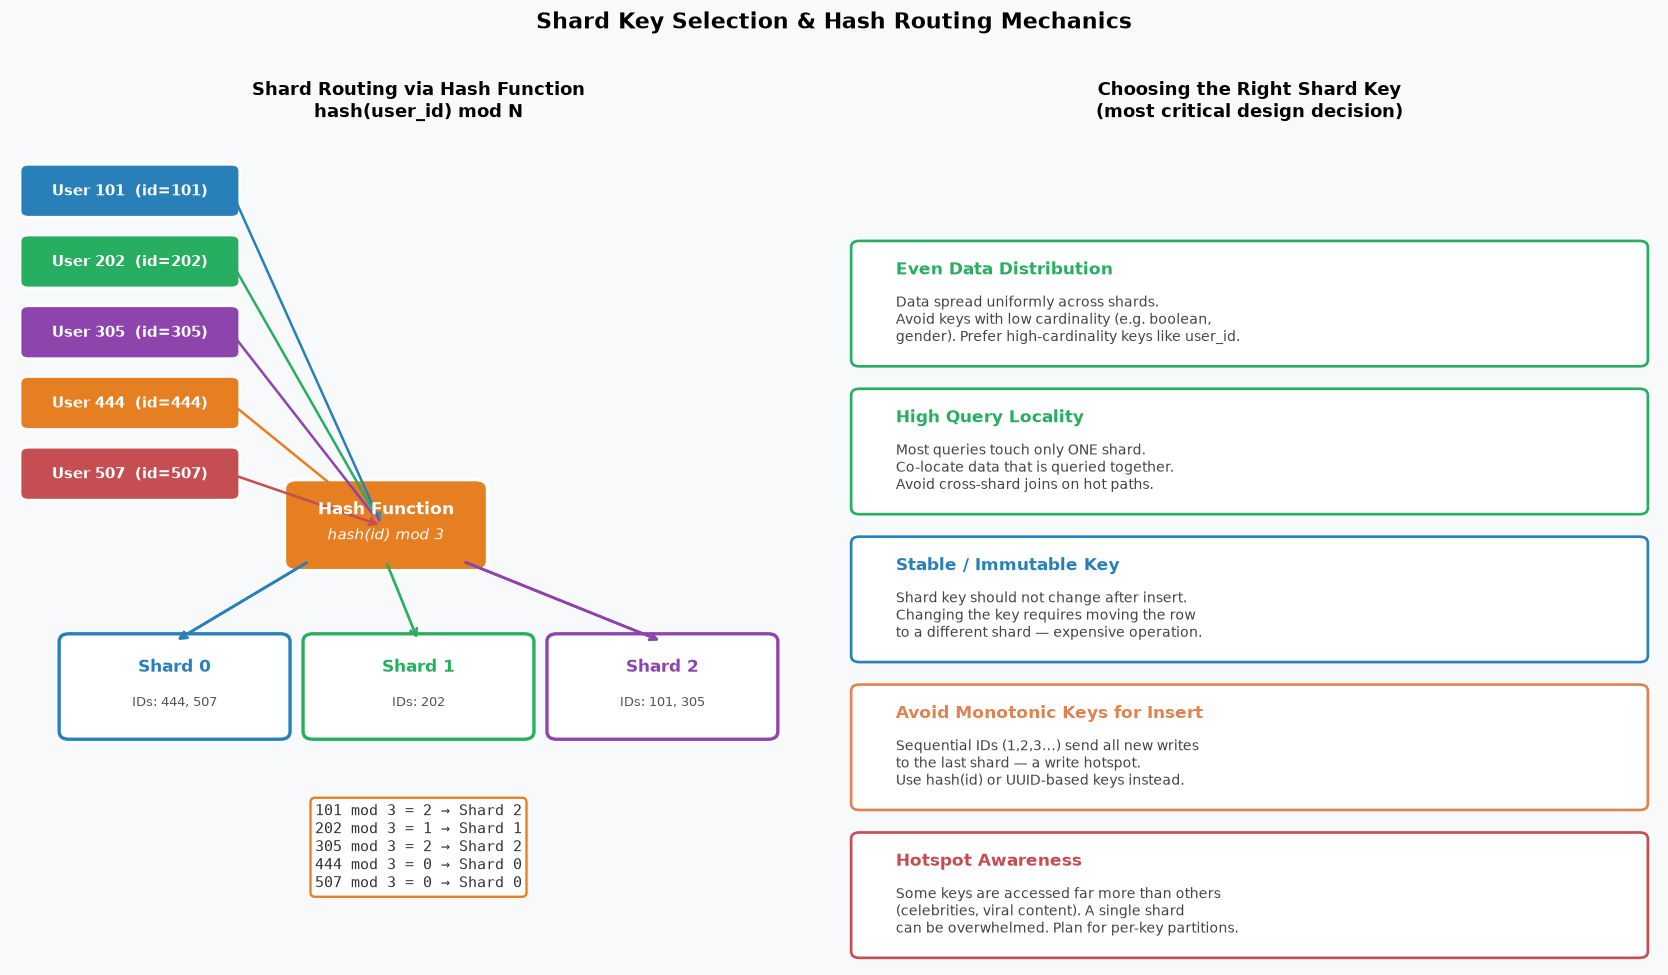

In [3]:
# Hash function routing and shard key mechanics

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: hash function routing mechanics ─────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Shard Routing via Hash Function\nhash(user_id) mod N', fontsize=11, fontweight='bold')

users = [
    ('User 101',  101, '#2980B9'),
    ('User 202',  202, '#27AE60'),
    ('User 305',  305, '#8E44AD'),
    ('User 444',  444, '#E67E22'),
    ('User 507',  507, '#C44E52'),
]

y_start = 12.0
for i, (lbl, uid, col) in enumerate(users):
    yp = y_start - i * 1.1
    r = FancyBboxPatch((0.2, yp - 0.3), 2.5, 0.62,
                       boxstyle='round,pad=0.1',
                       facecolor=col, edgecolor='white', lw=1.5)
    ax.add_patch(r)
    ax.text(1.45, yp, f'{lbl}  (id={uid})', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    ax.annotate('', xy=(4.55, 6.8), xytext=(2.7, yp),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5,
                                connectionstyle='arc3,rad=0.0'))

# Hash function box
r = FancyBboxPatch((3.5, 6.25), 2.2, 1.12,
                   boxstyle='round,pad=0.15',
                   facecolor=C_HASH, edgecolor='white', lw=2.2)
ax.add_patch(r)
ax.text(4.6, 7.05, 'Hash Function', ha='center', va='center',
        fontsize=10, fontweight='bold', color='white')
ax.text(4.6, 6.65, 'hash(id) mod 3', ha='center', va='center',
        fontsize=9, color='white', fontstyle='italic')

# Shard results
shard_col = {0: '#2980B9', 1: '#27AE60', 2: '#8E44AD'}
results = [(uid % 3, uid, col) for (_, uid, col) in users]

shard_positions = {0: 2.0, 1: 5.0, 2: 8.0}
for sh in range(3):
    sx = shard_positions[sh]
    r = FancyBboxPatch((sx - 1.3, 3.6), 2.6, 1.4,
                       boxstyle='round,pad=0.12',
                       facecolor='white', edgecolor=shard_col[sh], lw=2.0)
    ax.add_patch(r)
    ax.text(sx, 4.6, f'Shard {sh}', ha='center', va='center',
            fontsize=10, fontweight='bold', color=shard_col[sh])
    users_in = [uid for (s, uid, _) in results if s == sh]
    ax.text(sx, 4.05, 'IDs: ' + ', '.join(str(u) for u in users_in),
            ha='center', va='center', fontsize=8, color='#555')

for sh, uid, col in results:
    ax.annotate('', xy=(shard_positions[sh], 5.0),
                xytext=(4.6 + 1.1 * (shard_positions[sh] - 5.0) / 3.5, 6.25),
                arrowprops=dict(arrowstyle='->', color=shard_col[sh], lw=1.6))

ax.text(5.0, 1.8,
        '101 mod 3 = 2 → Shard 2\n'
        '202 mod 3 = 1 → Shard 1\n'
        '305 mod 3 = 2 → Shard 2\n'
        '444 mod 3 = 0 → Shard 0\n'
        '507 mod 3 = 0 → Shard 0',
        ha='center', va='center', fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_HASH, lw=1.4),
        family='monospace')

# ── Right: shard key choice criteria ──────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Choosing the Right Shard Key\n(most critical design decision)', fontsize=11, fontweight='bold')

criteria = [
    (C_OK,       'Even Data Distribution',
     'Data spread uniformly across shards.\n'
     'Avoid keys with low cardinality (e.g. boolean,\n'
     'gender). Prefer high-cardinality keys like user_id.'),
    (C_OK,       'High Query Locality',
     'Most queries touch only ONE shard.\n'
     'Co-locate data that is queried together.\n'
     'Avoid cross-shard joins on hot paths.'),
    (C_SHARD,    'Stable / Immutable Key',
     'Shard key should not change after insert.\n'
     'Changing the key requires moving the row\n'
     'to a different shard — expensive operation.'),
    (C_ORANGE,   'Avoid Monotonic Keys for Insert',
     'Sequential IDs (1,2,3…) send all new writes\n'
     'to the last shard — a write hotspot.\n'
     'Use hash(id) or UUID-based keys instead.'),
    (C_HOT,      'Hotspot Awareness',
     'Some keys are accessed far more than others\n'
     '(celebrities, viral content). A single shard\n'
     'can be overwhelmed. Plan for per-key partitions.'),
]

y0 = 12.5
for (color, title, detail) in criteria:
    y0 -= 2.3
    r = FancyBboxPatch((0.2, y0 - 0.82), 9.6, 1.75,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.6)
    ax.add_patch(r)
    ax.text(0.65, y0 + 0.58, title, ha='left', va='center',
            fontsize=10, fontweight='bold', color=color)
    ax.text(0.65, y0 - 0.2, detail, ha='left', va='center',
            fontsize=8.5, color='#444')

plt.suptitle('Shard Key Selection & Hash Routing Mechanics',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day10_shard_key.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Hash routing trace for 5 users:**  
Five user IDs (101, 202, 305, 444, 507) flow from coloured user boxes into the amber hash function box (`hash(id) mod 3`). Arrows fan out to three shards based on the modulo result. The lookup table at the bottom shows the exact arithmetic for each ID.

**Right — Shard key criteria:**  
Five criteria cards with colour coding: green cards are requirements for a good key, orange card warns about monotonic IDs, red card warns about hotspot keys. Each card includes both the rule and the practical consequence of violating it.

## 4. Resharding & Consistent Hashing

> "Resharding data is needed when: (1) a single shard could no longer hold more data due to rapid growth, (2) certain shards might experience shard exhaustion faster than others due to uneven data distribution. Consistent hashing is a commonly used technique." — Day 10

**The resharding problem:**
If you have 3 shards and add a 4th, `hash(id) mod 3` and `hash(id) mod 4` produce different results for every key. In a naive rehash, approximately 75% of all data must move to a new shard — an expensive, risky online migration.

**Consistent hashing solution:**
Map both keys and shard nodes onto a virtual ring (0–359 degrees). Each key is assigned to the next clockwise shard node on the ring. When a new shard is added, **only keys between the new node and its predecessor move** — on average 1/N of total data, where N is the number of shards.

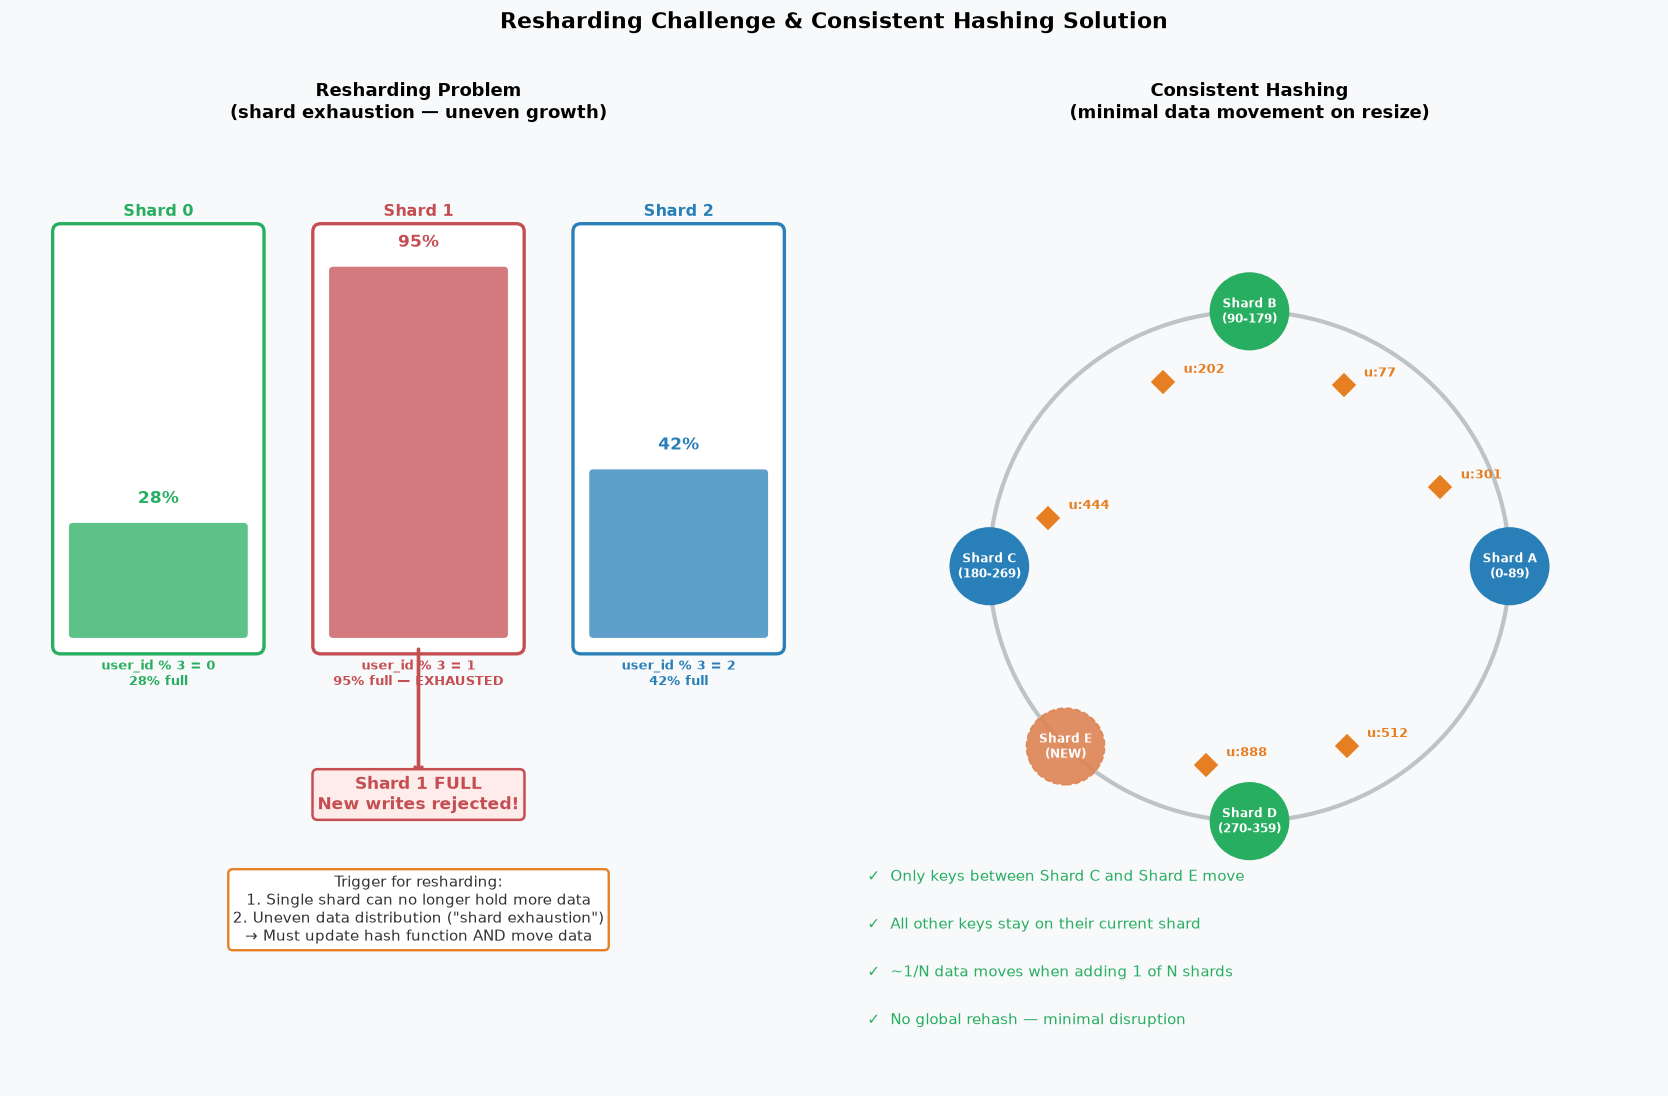

In [4]:
# Resharding: the challenge of rebalancing data as the cluster grows

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

# ── Left: before rehash — uneven shards ───────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Resharding Problem\n(shard exhaustion — uneven growth)',
             fontsize=11, fontweight='bold')

# Show 3 shards, one full
shard_fills = [
    ('Shard 0', 0.28, C_OK,     'user_id % 3 = 0\n28% full'),
    ('Shard 1', 0.95, C_HOT,    'user_id % 3 = 1\n95% full — EXHAUSTED'),
    ('Shard 2', 0.42, C_SHARD,  'user_id % 3 = 2\n42% full'),
]
xs = [1.8, 5.0, 8.2]

for (slbl, fill, color, sub), sx in zip(shard_fills, xs):
    # Container
    r = FancyBboxPatch((sx - 1.2, 5.5), 2.4, 5.2,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=2.0)
    ax.add_patch(r)
    # Fill bar
    fill_h = fill * 4.8
    r2 = FancyBboxPatch((sx - 1.05, 5.65), 2.1, fill_h,
                        boxstyle='round,pad=0.05',
                        facecolor=color, edgecolor='none', alpha=0.75)
    ax.add_patch(r2)
    ax.text(sx, 10.95, slbl, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(sx, 5.15, sub, ha='center', va='center',
            fontsize=7.5, color=color, fontweight='bold')
    ax.text(sx, 5.65 + fill_h + 0.25, f'{int(fill*100)}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

# Overflow arrow from shard 1
ax.annotate('', xy=(5.0, 3.8), xytext=(5.0, 5.5),
            arrowprops=dict(arrowstyle='->', color=C_HOT, lw=2.2))
ax.text(5.0, 3.45, 'Shard 1 FULL\nNew writes rejected!',
        ha='center', fontsize=10, color=C_HOT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDECEA',
                  edgecolor=C_HOT, lw=1.5))

ax.text(5.0, 1.8,
        'Trigger for resharding:\n'
        '1. Single shard can no longer hold more data\n'
        '2. Uneven data distribution ("shard exhaustion")\n'
        '→ Must update hash function AND move data',
        ha='center', fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_HASH, lw=1.4))

# ── Right: consistent hashing — the solution ──────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Consistent Hashing\n(minimal data movement on resize)',
             fontsize=11, fontweight='bold')

# Draw hash ring
theta = np.linspace(0, 2*np.pi, 300)
cx, cy, radius = 5.0, 6.5, 3.2
ax.plot(cx + radius * np.cos(theta),
        cy + radius * np.sin(theta),
        color='#BDC3C7', lw=2.5, zorder=1)

# 4 server nodes on the ring
node_angles = [0, np.pi/2, np.pi, 3*np.pi/2]
node_labels = ['Shard A\n(0-89)', 'Shard B\n(90-179)', 'Shard C\n(180-269)', 'Shard D\n(270-359)']
node_colors = [C_SHARD, C_OK, C_SHARD, C_OK]

for angle, lbl, col in zip(node_angles, node_labels, node_colors):
    nx = cx + radius * np.cos(angle)
    ny = cy + radius * np.sin(angle)
    circle = plt.Circle((nx, ny), 0.48, color=col, zorder=3)
    ax.add_patch(circle)
    ax.text(nx, ny, lbl, ha='center', va='center',
            fontsize=7, fontweight='bold', color='white', zorder=4)

# Data keys on the ring
key_angles = [0.4, 1.1, 2.0, 2.9, 4.5, 5.2]
key_labels = ['u:301', 'u:77', 'u:202', 'u:444', 'u:888', 'u:512']
key_colors = [C_HASH, C_HASH, C_HASH, C_HASH, C_HASH, C_HASH]

for angle, lbl, col in zip(key_angles, key_labels, key_colors):
    kx = cx + (radius - 0.65) * np.cos(angle)
    ky = cy + (radius - 0.65) * np.sin(angle)
    ax.plot(kx, ky, 'D', color=col, ms=9, zorder=3)
    ax.text(kx + 0.25, ky + 0.15, lbl, ha='left', va='center',
            fontsize=7.5, color=col, fontweight='bold')

# NEW node being added
new_angle = np.pi * 1.25
nx = cx + radius * np.cos(new_angle)
ny = cy + radius * np.sin(new_angle)
circle = plt.Circle((nx, ny), 0.48, color=C_ORANGE, zorder=3,
                    linestyle='--', fill=True, alpha=0.9)
ax.add_patch(circle)
ax.text(nx, ny, 'Shard E\n(NEW)', ha='center', va='center',
        fontsize=7, fontweight='bold', color='white', zorder=4)

benefits_text = [
    '✓  Only keys between Shard C and Shard E move',
    '✓  All other keys stay on their current shard',
    '✓  ~1/N data moves when adding 1 of N shards',
    '✓  No global rehash — minimal disruption',
]
y0 = 2.6
for pt in benefits_text:
    ax.text(0.3, y0, pt, ha='left', va='center', fontsize=9, color=C_OK)
    y0 -= 0.6

plt.suptitle('Resharding Challenge & Consistent Hashing Solution',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day10_resharding.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Shard exhaustion:**  
Three shards shown as vertical fill bars. Shard 0 (28% full) and Shard 2 (42%) are healthy. Shard 1 (95%) is highlighted red with a downward overflow arrow: new writes are rejected. This is the trigger for resharding.

**Right — Consistent hashing ring:**  
Four shard nodes (A, B, C, D) placed at 0°, 90°, 180°, 270° on a circular ring. Six key diamonds are placed at their hash positions on the ring. A new Shard E (orange) is inserted between C and D. Only the keys that fall between C and E must migrate — all other keys stay in place. The benefit list confirms: ~1/N data moves, no global rehash.

## 5. Celebrity Problem (Hotspot Key)

> "Celebrity problem: also called the hotspot key problem. Excessive access to a specific shard could cause server overload. Imagine data for Cristiano Ronaldo and Virat Kohli end up on the same shard. For social applications, that shard will be overwhelmed with read operations. To solve this, we may allocate a shard to each celebrity. Each shard might even require further partition." — Day 10

**Why hotspots occur:**
Hash-based sharding distributes *keys* evenly, but not *traffic*. Ronaldo's profile receives 500M more reads per day than an average user's profile. Even with uniform key distribution, one shard handles a disproportionate query load.

**The four mitigation strategies:**
1. Dedicated shard per celebrity (as prescribed in the post)
2. Key salting — scatter writes to N sub-shards, merge on read
3. Read replicas on the hot shard
4. Application-layer caching (Redis) to absorb read traffic

/tmp/ipykernel_350548/822614448.py:144: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_350548/822614448.py:145: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/sd_day10_celebrity.png', dpi=130, bbox_inches='tight')


/home/participant/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


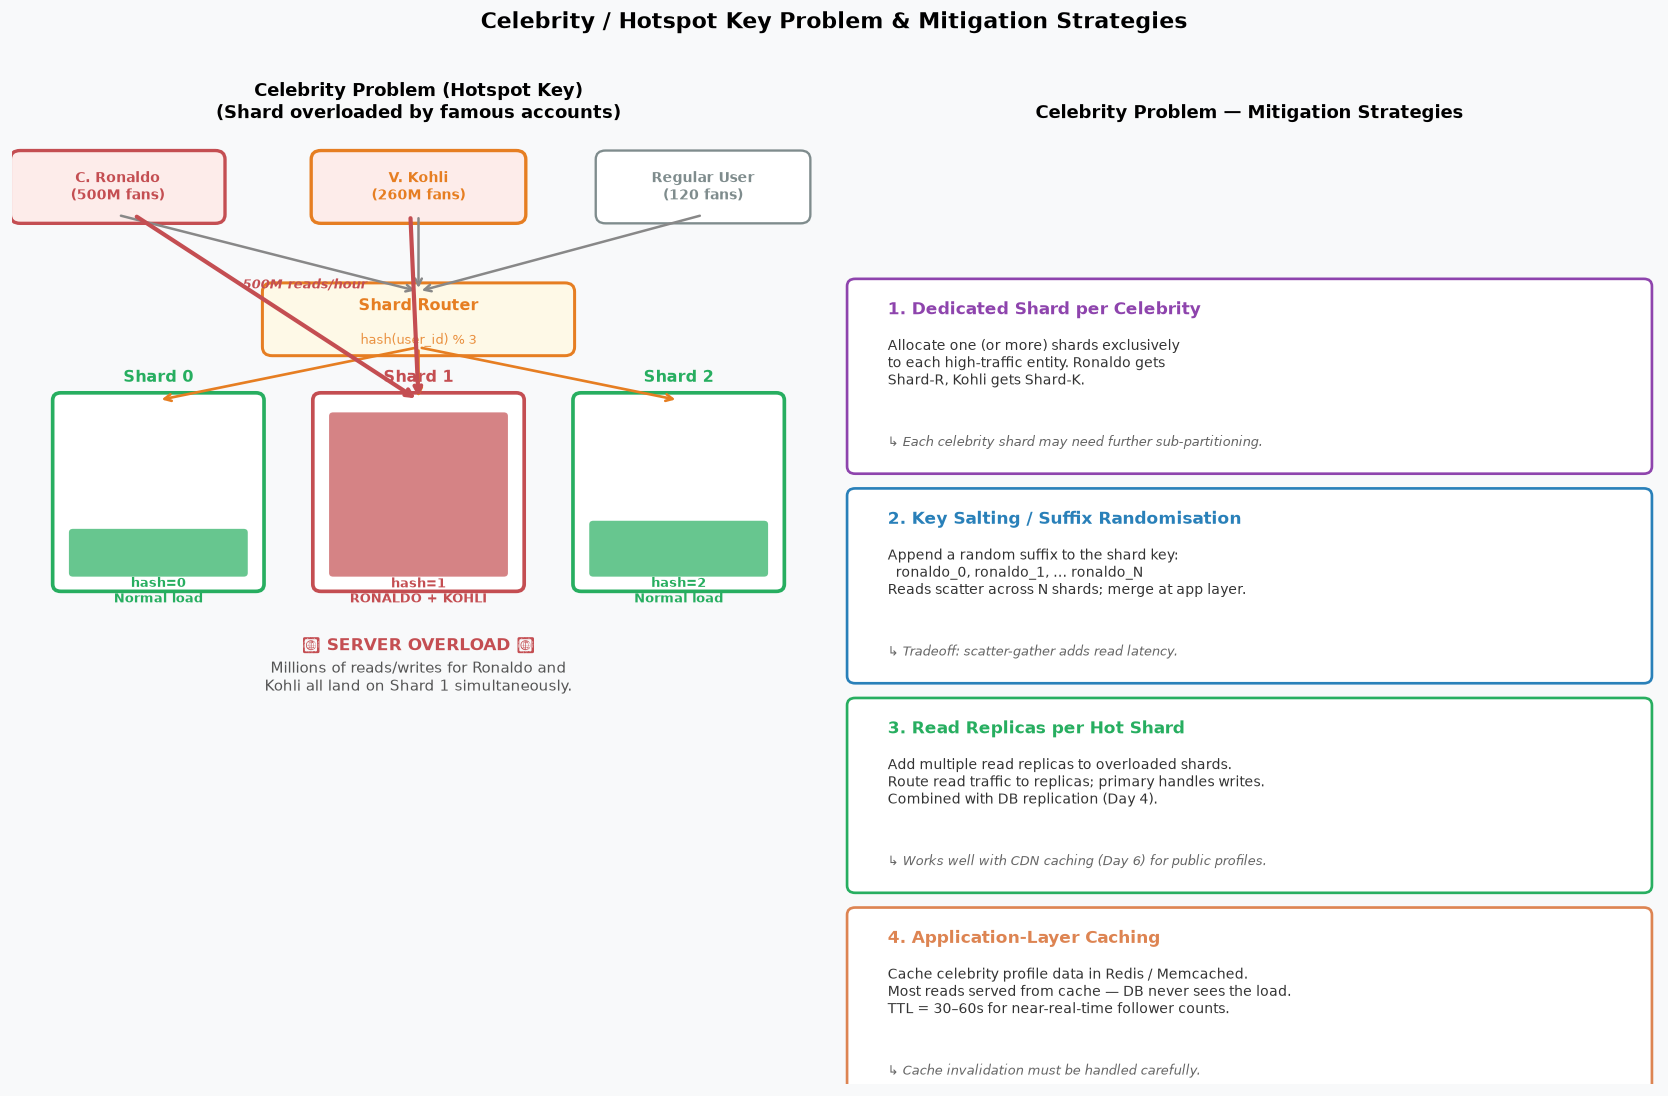

In [5]:
# Celebrity / hotspot key problem and mitigation strategies

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.1
        ax.text(mx, my, label, ha='left', va='center', fontsize=8,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Left: the celebrity problem ───────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Celebrity Problem (Hotspot Key)\n(Shard overloaded by famous accounts)',
             fontsize=11, fontweight='bold')

# Users
user_data = [
    (1.3, 12.2, 'C. Ronaldo\n(500M fans)', '#C44E52',  True),
    (5.0, 12.2, 'V. Kohli\n(260M fans)',   '#E67E22',  True),
    (8.5, 12.2, 'Regular User\n(120 fans)', '#7F8C8D', False),
]
for (ux, uy, ulbl, uc, hot) in user_data:
    rbox(ax, ux, uy, 2.4, 0.75, ulbl, uc,
         bg='#FDECEA' if hot else 'white', fs=8.5, lw=2.0 if hot else 1.4)

# Hash router
rbox(ax, 5.0, 10.4, 3.6, 0.75, 'Shard Router', C_HASH,
     bg='#FEF9E7', sub='hash(user_id) % 3', fs=9.5)

for ux, uy, *_ in user_data:
    ax.annotate('', xy=(5.0, 10.78), xytext=(ux, uy - 0.38),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.5))

# Three shards — shard 1 overloaded
shards = [
    (1.8, 'Shard 0',   C_OK,  'hash=0\nNormal load',       0.25),
    (5.0, 'Shard 1',   C_HOT, 'hash=1\nRONALDO + KOHLI',  0.97),
    (8.2, 'Shard 2',   C_OK,  'hash=2\nNormal load',       0.30),
]
for sx, slbl, col, ssub, fill in shards:
    # outer box
    r = FancyBboxPatch((sx - 1.2, 6.8), 2.4, 2.5,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=col, lw=2.2)
    ax.add_patch(r)
    fill_h = fill * 2.2
    r2 = FancyBboxPatch((sx - 1.05, 6.95), 2.1, fill_h,
                        boxstyle='round,pad=0.05',
                        facecolor=col, edgecolor='none', alpha=0.7)
    ax.add_patch(r2)
    ax.text(sx, 9.55, slbl, ha='center', fontsize=9.5, fontweight='bold', color=col)
    ax.text(sx, 6.55, ssub, ha='center', fontsize=7.5, color=col, fontweight='bold')

for sx in [1.8, 5.0, 8.2]:
    ax.annotate('', xy=(sx, 9.3), xytext=(5.0, 10.02),
                arrowprops=dict(arrowstyle='->', color=C_HASH, lw=1.6))

# Fire explosion on shard 1
ax.text(5.0, 5.9, '🔥 SERVER OVERLOAD 🔥',
        ha='center', fontsize=10, color=C_HOT, fontweight='bold')
ax.text(5.0, 5.35,
        'Millions of reads/writes for Ronaldo and\n'
        'Kohli all land on Shard 1 simultaneously.',
        ha='center', fontsize=9, color='#555')

# Read ops annotation
ax.annotate('', xy=(5.0, 9.3), xytext=(1.5, 11.82),
            arrowprops=dict(arrowstyle='->', color=C_HOT, lw=2.5))
ax.annotate('', xy=(5.0, 9.3), xytext=(4.9, 11.82),
            arrowprops=dict(arrowstyle='->', color=C_HOT, lw=2.5))

ax.text(3.6, 10.82, '500M reads/hour', ha='center', fontsize=7.5,
        color=C_HOT, fontstyle='italic', fontweight='bold')

# ── Right: mitigation strategies ──────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Celebrity Problem — Mitigation Strategies',
             fontsize=11, fontweight='bold')

strategies = [
    (C_CELEBRITY,
     '1. Dedicated Shard per Celebrity',
     'Allocate one (or more) shards exclusively\n'
     'to each high-traffic entity. Ronaldo gets\n'
     'Shard-R, Kohli gets Shard-K.',
     'Each celebrity shard may need further sub-partitioning.'),
    (C_SHARD,
     '2. Key Salting / Suffix Randomisation',
     'Append a random suffix to the shard key:\n'
     '  ronaldo_0, ronaldo_1, … ronaldo_N\n'
     'Reads scatter across N shards; merge at app layer.',
     'Tradeoff: scatter-gather adds read latency.'),
    (C_OK,
     '3. Read Replicas per Hot Shard',
     'Add multiple read replicas to overloaded shards.\n'
     'Route read traffic to replicas; primary handles writes.\n'
     'Combined with DB replication (Day 4).',
     'Works well with CDN caching (Day 6) for public profiles.'),
    (C_ORANGE,
     '4. Application-Layer Caching',
     'Cache celebrity profile data in Redis / Memcached.\n'
     'Most reads served from cache — DB never sees the load.\n'
     'TTL = 30–60s for near-real-time follower counts.',
     'Cache invalidation must be handled carefully.'),
]

y0 = 12.4
for (color, title, body, note) in strategies:
    y0 -= 2.85
    r = FancyBboxPatch((0.15, y0 - 1.15), 9.7, 2.45,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.6)
    ax.add_patch(r)
    ax.text(0.55, y0 + 0.98, title, ha='left', va='center',
            fontsize=10, fontweight='bold', color=color)
    ax.text(0.55, y0 + 0.25, body, ha='left', va='center',
            fontsize=8.5, color='#333')
    ax.text(0.55, y0 - 0.82, f'↳ {note}', ha='left', va='center',
            fontsize=8, color='#666', fontstyle='italic')

plt.suptitle('Celebrity / Hotspot Key Problem & Mitigation Strategies',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day10_celebrity.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — The celebrity problem:**  
Ronaldo (500M fans) and Kohli (260M fans) both hash to Shard 1. Heavy arrows from both celebrities converge on Shard 1, shown 97% full and red. A 'SERVER OVERLOAD' annotation marks the failure. Shard 0 (25%) and Shard 2 (30%) are under-utilised — the imbalance is caused by traffic skew, not data volume.

**Right — Mitigation strategies:**  
Four solution cards with increasing complexity: dedicated shard (simplest, matches the post's recommendation), key salting (scatter writes), read replicas (works with Day 4 replication), and application-layer caching (works with Day 5 cache).

## 6. Cross-Shard JOINs & Denormalisation

> "It's hard to perform join operations across database shards. Common workaround is to de-normalise the database so that queries can be performed in a single database." — Day 10

**Why JOINs break across shards:**
A SQL JOIN requires the query planner to access both tables in the same execution context. When `users` is on Shard A and `posts` is on Shard B (different servers), there is no shared query planner that can execute the JOIN. The application must fetch from both shards and merge the result sets in memory — expensive and complex.

**Denormalisation:**
Copy the data you need from the joined table directly into the querying table. For the posts/users example: store `username` and `avatar_url` inside each `post` row. This eliminates the JOIN at the cost of data duplication and update anomalies.

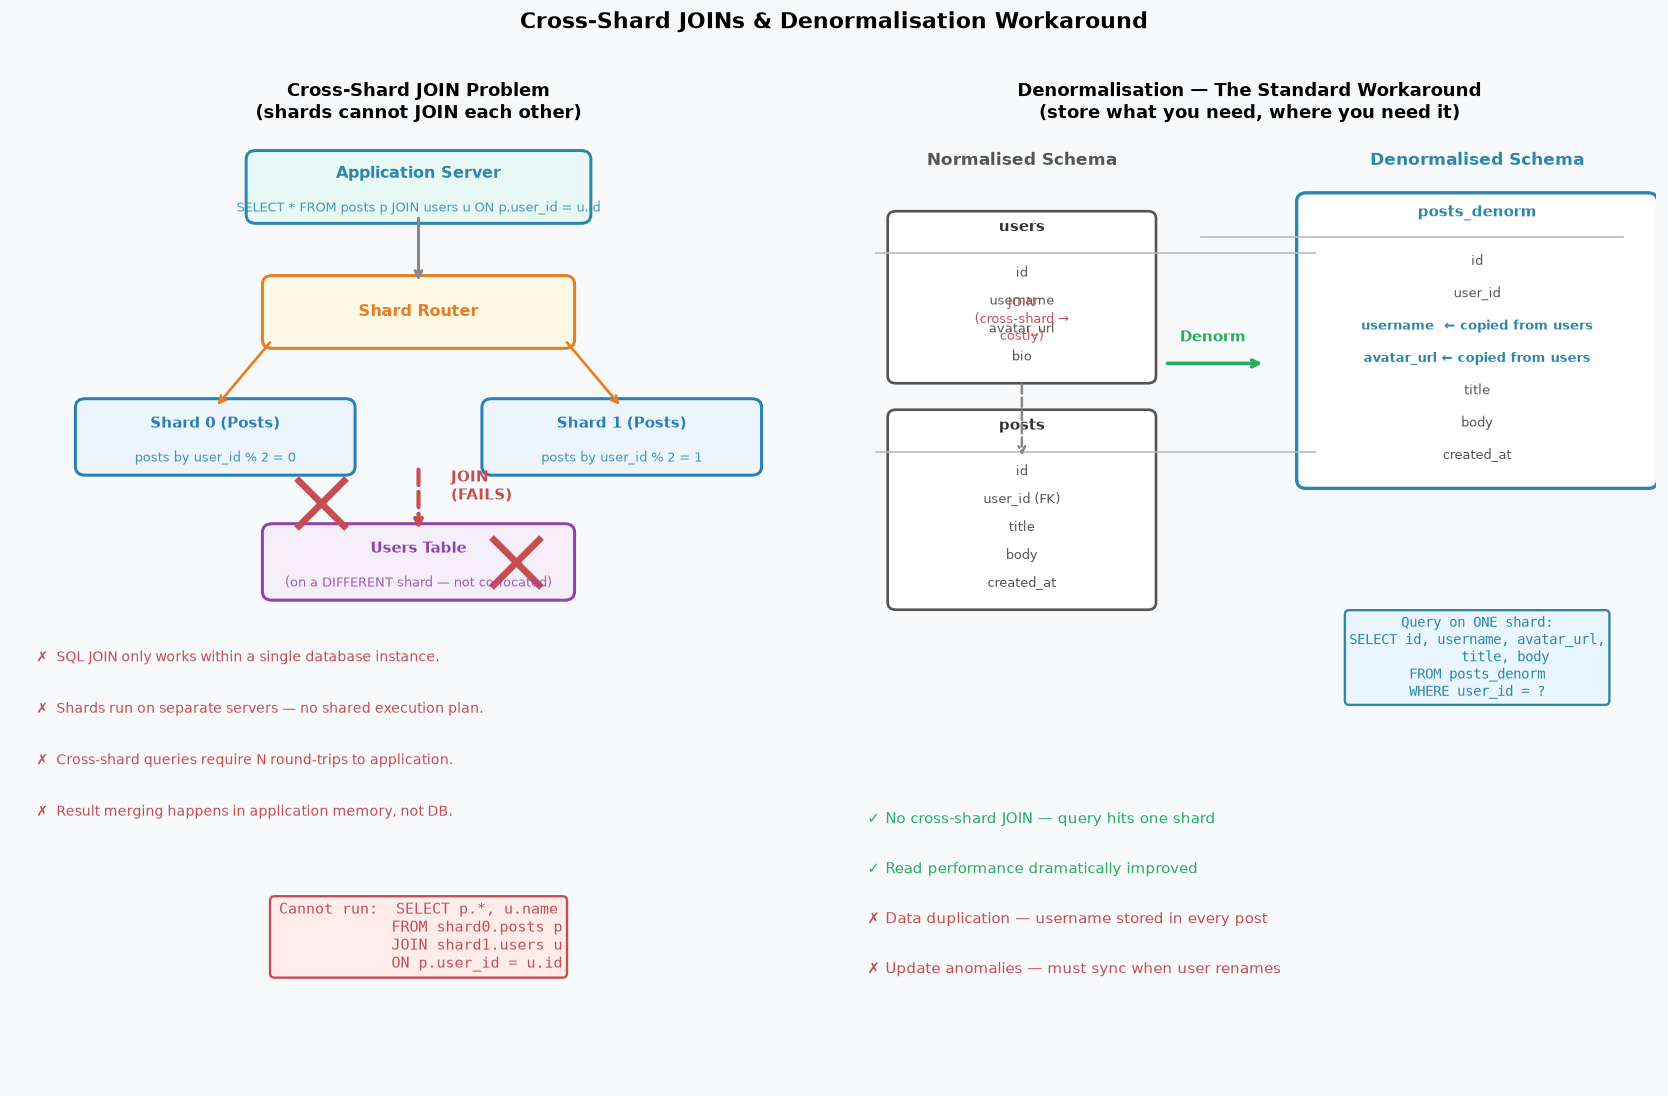

In [6]:
# Cross-shard joins and denormalization strategy

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85)

# ── Left: the cross-shard join problem ────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Cross-Shard JOIN Problem\n(shards cannot JOIN each other)',
             fontsize=11, fontweight='bold')

# Application layer
rbox(ax, 5.0, 12.2, 4.0, 0.75, 'Application Server', C_TEAL,
     bg='#E8F8F5', sub='SELECT * FROM posts p JOIN users u ON p.user_id = u.id', fs=9.5)

# Shard router
rbox(ax, 5.0, 10.5, 3.6, 0.75, 'Shard Router', C_HASH,
     bg='#FEF9E7', fs=9.5)
ax.annotate('', xy=(5.0, 10.88), xytext=(5.0, 11.82),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.8))

# Posts shard (left)
rbox(ax, 2.5, 8.8, 3.2, 0.8, 'Shard 0 (Posts)', C_SHARD,
     bg='#EBF5FB', sub='posts by user_id % 2 = 0', fs=9)
ax.annotate('', xy=(2.5, 9.2), xytext=(3.2, 10.12),
            arrowprops=dict(arrowstyle='->', color=C_HASH, lw=1.6))

# Users shard (right)
rbox(ax, 7.5, 8.8, 3.2, 0.8, 'Shard 1 (Posts)', C_SHARD,
     bg='#EBF5FB', sub='posts by user_id % 2 = 1', fs=9)
ax.annotate('', xy=(7.5, 9.2), xytext=(6.8, 10.12),
            arrowprops=dict(arrowstyle='->', color=C_HASH, lw=1.6))

# Separate users table (completely different shard)
rbox(ax, 5.0, 7.1, 3.6, 0.8, 'Users Table', C_CELEBRITY,
     bg='#F5EEF8', sub='(on a DIFFERENT shard — not co-located)', fs=9)

# Big X over the JOIN arrow
ax.plot([3.8, 6.2], [7.9, 7.1], 'x', ms=30, mew=4, color=C_HOT)

ax.annotate('', xy=(5.0, 7.5), xytext=(5.0, 8.4),
            arrowprops=dict(arrowstyle='->', color=C_HOT, lw=2.5,
                            linestyle='dashed'))
ax.text(5.4, 7.95, 'JOIN\n(FAILS)', ha='left', fontsize=9,
        color=C_HOT, fontweight='bold')

problems = [
    'SQL JOIN only works within a single database instance.',
    'Shards run on separate servers — no shared execution plan.',
    'Cross-shard queries require N round-trips to application.',
    'Result merging happens in application memory, not DB.',
]
y0 = 5.8
for pt in problems:
    ax.text(0.3, y0, f'✗  {pt}', ha='left', va='center', fontsize=8.5, color=C_HOT)
    y0 -= 0.7

ax.text(5.0, 2.0,
        'Cannot run:  SELECT p.*, u.name\n'
        '             FROM shard0.posts p\n'
        '             JOIN shard1.users u\n'
        '             ON p.user_id = u.id',
        ha='center', va='center', fontsize=9, color=C_HOT,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDECEA',
                  edgecolor=C_HOT, lw=1.4),
        family='monospace')

# ── Right: denormalization workaround ─────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Denormalisation — The Standard Workaround\n(store what you need, where you need it)',
             fontsize=11, fontweight='bold')

# Normalised schema (left column)
ax.text(2.2, 12.5, 'Normalised Schema', ha='center', fontsize=10,
        fontweight='bold', color='#555')

norm_tables = [
    (2.2, 11.4, 'users', ['id', 'username', 'avatar_url', 'bio']),
    (2.2,  8.7, 'posts',  ['id', 'user_id (FK)', 'title', 'body', 'created_at']),
]
for tx, ty, tname, cols in norm_tables:
    r = FancyBboxPatch((tx - 1.55, ty - len(cols)*0.38 - 0.25), 3.1, len(cols)*0.38 + 0.62,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor='#555', lw=1.6)
    ax.add_patch(r)
    ax.text(tx, ty + 0.2, tname, ha='center', fontsize=9, fontweight='bold', color='#333')
    ax.axhline(ty - 0.1, xmin=0.04, xmax=0.58, color='#bbb', lw=1.0)
    for i, col in enumerate(cols):
        ax.text(tx, ty - 0.42 - i * 0.38, col, ha='center', fontsize=8, color='#555')

ax.annotate('', xy=(2.2, 8.4 + 0.1), xytext=(2.2, 11.4 - len(norm_tables[0][3])*0.38 - 0.62 + 0.3),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.5,
                            linestyle='dashed'))
ax.text(2.2, 10.12, 'JOIN\n(cross-shard →\ncostly)', ha='center', fontsize=8,
        color=C_HOT)

# Arrow right
ax.annotate('', xy=(5.2, 9.8), xytext=(3.95, 9.8),
            arrowprops=dict(arrowstyle='->', color=C_OK, lw=2.2))
ax.text(4.55, 10.1, 'Denorm', ha='center', fontsize=9,
        color=C_OK, fontweight='bold')

# Denormalised schema (right column)
ax.text(7.8, 12.5, 'Denormalised Schema', ha='center', fontsize=10,
        fontweight='bold', color=C_DENORM)

denorm_cols = [
    'id',
    'user_id',
    'username  ← copied from users',
    'avatar_url ← copied from users',
    'title',
    'body',
    'created_at',
]
tx2, ty2 = 7.8, 11.6
r = FancyBboxPatch((tx2 - 2.1, ty2 - len(denorm_cols)*0.44 - 0.3), 4.2,
                   len(denorm_cols)*0.44 + 0.7,
                   boxstyle='round,pad=0.12',
                   facecolor='white', edgecolor=C_DENORM, lw=2.0)
ax.add_patch(r)
ax.text(tx2, ty2 + 0.2, 'posts_denorm', ha='center', fontsize=9,
        fontweight='bold', color=C_DENORM)
ax.axhline(ty2 - 0.08, xmin=0.44, xmax=0.96, color='#bbb', lw=1.0)
for i, col in enumerate(denorm_cols):
    c = C_DENORM if '←' in col else '#555'
    ax.text(tx2, ty2 - 0.46 - i * 0.44, col, ha='center', fontsize=8,
            color=c, fontweight='bold' if '←' in col else 'normal')

ax.text(7.8, 5.8,
        'Query on ONE shard:\n'
        'SELECT id, username, avatar_url,\n'
        '       title, body\n'
        'FROM posts_denorm\n'
        'WHERE user_id = ?',
        ha='center', va='center', fontsize=8.5, color=C_DENORM,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#EAF6FF',
                  edgecolor=C_DENORM, lw=1.4),
        family='monospace')

tradeoffs = [
    (C_OK,  '✓ No cross-shard JOIN — query hits one shard'),
    (C_OK,  '✓ Read performance dramatically improved'),
    (C_HOT, '✗ Data duplication — username stored in every post'),
    (C_HOT, '✗ Update anomalies — must sync when user renames'),
]
y0 = 3.6
for (col, txt) in tradeoffs:
    ax.text(0.3, y0, txt, ha='left', va='center', fontsize=9, color=col)
    y0 -= 0.68

plt.suptitle('Cross-Shard JOINs & Denormalisation Workaround',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day10_denorm.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Cross-shard JOIN failure:**  
An app server issues a JOIN query. The shard router sends posts to Shard 0 and Shard 1, but the users table lives on a completely different shard. A red X and dashed arrow mark the JOIN as impossible. The red code box at the bottom shows the query that cannot be executed.

**Right — Denormalisation solution:**  
A normalised schema (two separate tables connected by FK, requiring cross-shard JOIN) is transformed via a 'Denorm' arrow into a single `posts_denorm` table that embeds `username` and `avatar_url` (teal columns). The resulting query hits one shard only. The trade-off table at the bottom lists both the read gains and the data duplication / update anomaly costs.

## 7. Sharding Strategies Comparison

Beyond simple hash sharding, four main strategies are used in production:

| Strategy | Mechanism | Best For | Key Risk |
|---|---|---|---|
| **Range** | Split by value ranges | Time-series, ordered data | Hotspot on recent range |
| **Hash** | `hash(key) mod N` | General purpose, uniform write load | Range queries hit all shards |
| **Directory** | Lookup table maps key → shard | Celebrity accounts, special routing | Directory is a SPOF |
| **Geo** | Route by user's region | Low latency, data residency laws | Uneven region growth |

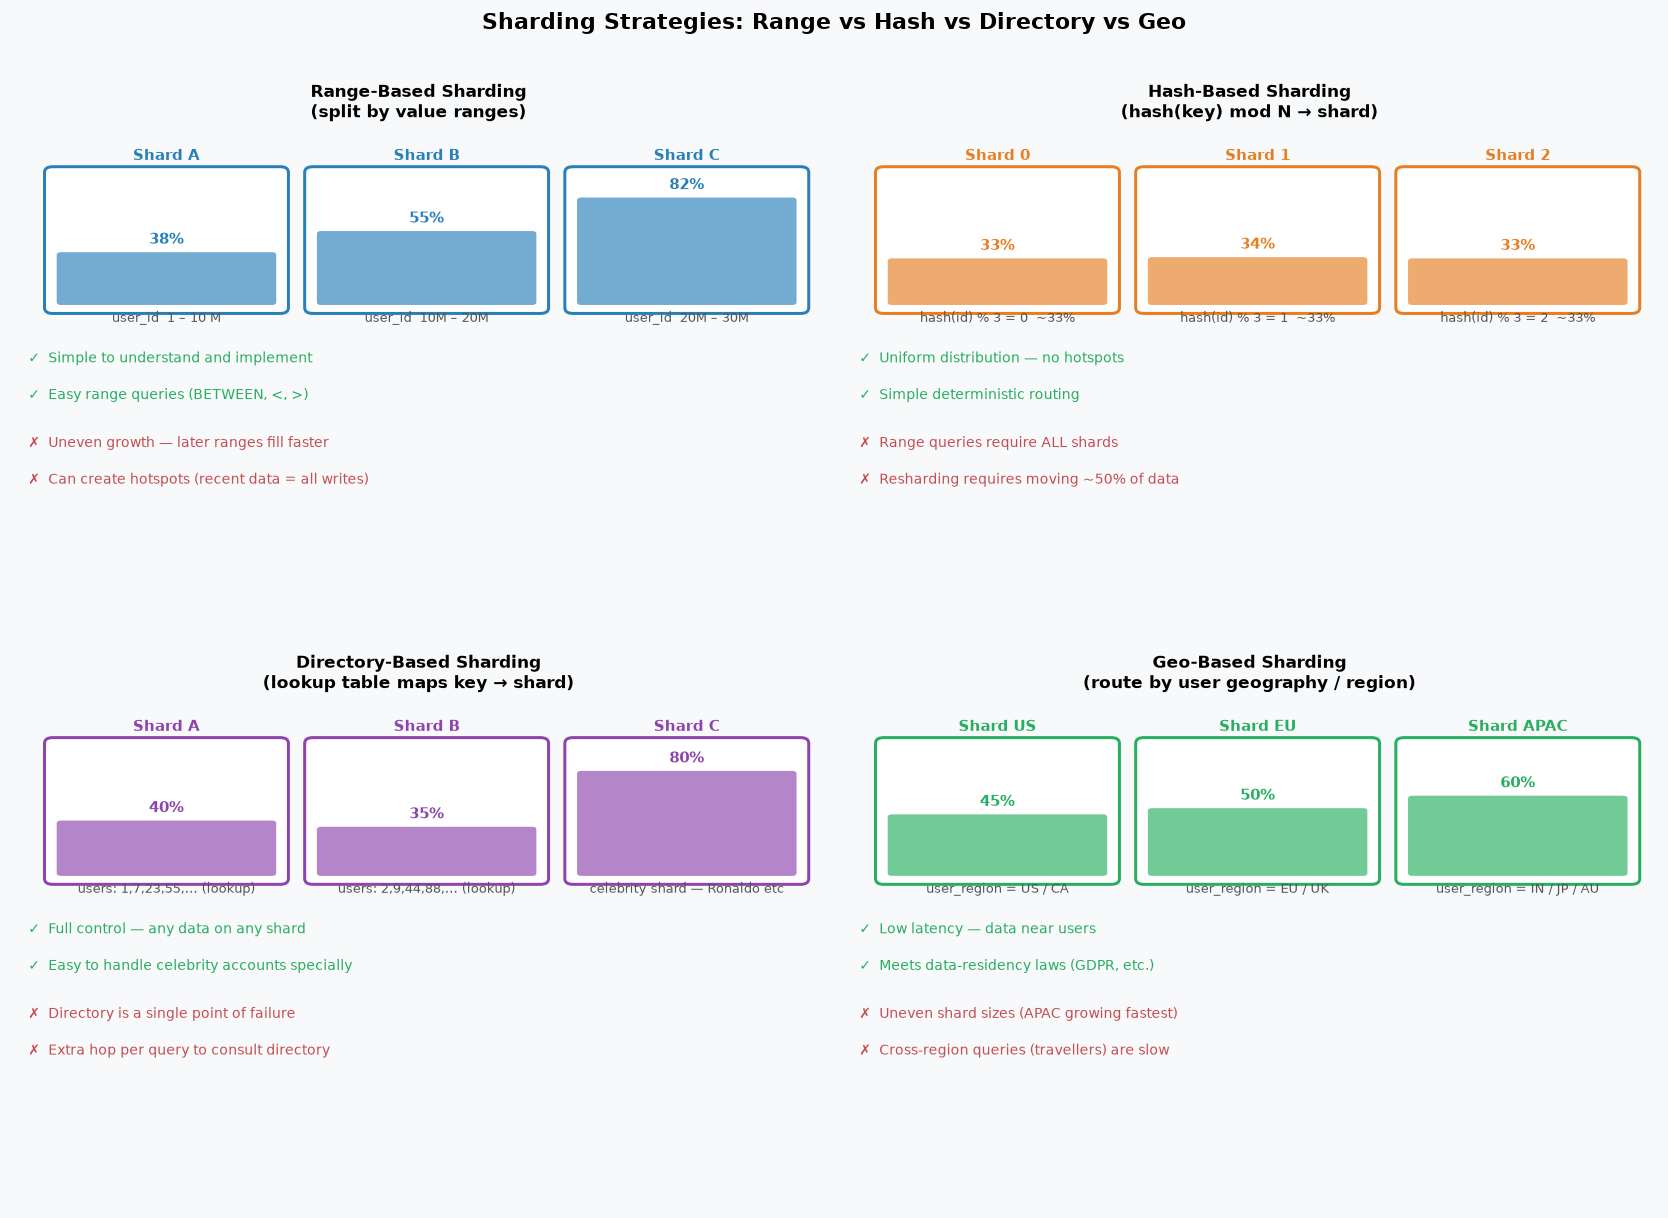

In [7]:
# Sharding strategies comparison: range, hash, directory, geo

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(C_GRAY)

strategies = [
    {
        'ax': axes[0][0],
        'title': 'Range-Based Sharding',
        'subtitle': 'split by value ranges',
        'color': C_SHARD,
        'shards': [
            ('Shard A', 'user_id  1 – 10 M',   0.38),
            ('Shard B', 'user_id  10M – 20M',  0.55),
            ('Shard C', 'user_id  20M – 30M',  0.82),   # growing fast
        ],
        'pros': ['Simple to understand and implement',
                 'Easy range queries (BETWEEN, <, >)'],
        'cons': ['Uneven growth — later ranges fill faster',
                 'Can create hotspots (recent data = all writes)'],
    },
    {
        'ax': axes[0][1],
        'title': 'Hash-Based Sharding',
        'subtitle': 'hash(key) mod N → shard',
        'color': C_HASH,
        'shards': [
            ('Shard 0', 'hash(id) % 3 = 0  ~33%', 0.33),
            ('Shard 1', 'hash(id) % 3 = 1  ~33%', 0.34),
            ('Shard 2', 'hash(id) % 3 = 2  ~33%', 0.33),
        ],
        'pros': ['Uniform distribution — no hotspots',
                 'Simple deterministic routing'],
        'cons': ['Range queries require ALL shards',
                 'Resharding requires moving ~50% of data'],
    },
    {
        'ax': axes[1][0],
        'title': 'Directory-Based Sharding',
        'subtitle': 'lookup table maps key → shard',
        'color': C_CELEBRITY,
        'shards': [
            ('Shard A', 'users: 1,7,23,55,… (lookup)', 0.40),
            ('Shard B', 'users: 2,9,44,88,… (lookup)', 0.35),
            ('Shard C', 'celebrity shard — Ronaldo etc', 0.80),
        ],
        'pros': ['Full control — any data on any shard',
                 'Easy to handle celebrity accounts specially'],
        'cons': ['Directory is a single point of failure',
                 'Extra hop per query to consult directory'],
    },
    {
        'ax': axes[1][1],
        'title': 'Geo-Based Sharding',
        'subtitle': 'route by user geography / region',
        'color': C_OK,
        'shards': [
            ('Shard US',  'user_region = US / CA', 0.45),
            ('Shard EU',  'user_region = EU / UK', 0.50),
            ('Shard APAC','user_region = IN / JP / AU', 0.60),
        ],
        'pros': ['Low latency — data near users',
                 'Meets data-residency laws (GDPR, etc.)'],
        'cons': ['Uneven shard sizes (APAC growing fastest)',
                 'Cross-region queries (travellers) are slow'],
    },
]

for s in strategies:
    ax = s['ax']
    ax.set_xlim(0, 10); ax.set_ylim(0, 9)
    ax.axis('off'); ax.set_facecolor(C_GRAY)
    ax.set_title(f"{s['title']}\n({s['subtitle']})",
                 fontsize=10, fontweight='bold')
    col = s['color']

    # Shard bars
    for i, (slbl, ssub, fill) in enumerate(s['shards']):
        bx = 0.5 + i * 3.2
        # Container
        r = FancyBboxPatch((bx, 5.8), 2.8, 2.4,
                           boxstyle='round,pad=0.1',
                           facecolor='white', edgecolor=col, lw=1.8)
        ax.add_patch(r)
        # Fill
        r2 = FancyBboxPatch((bx + 0.1, 5.9), 2.6, fill * 2.2,
                            boxstyle='round,pad=0.05',
                            facecolor=col, edgecolor='none', alpha=0.65)
        ax.add_patch(r2)
        ax.text(bx + 1.4, 8.42, slbl, ha='center', fontsize=9,
                fontweight='bold', color=col)
        ax.text(bx + 1.4, 5.55, ssub, ha='center', fontsize=7.5,
                color='#555')
        ax.text(bx + 1.4, 5.9 + fill * 2.2 + 0.2, f'{int(fill*100)}%',
                ha='center', fontsize=9, fontweight='bold', color=col)

    # Pros / cons
    y0 = 4.9
    for pt in s['pros']:
        ax.text(0.2, y0, f'✓  {pt}', ha='left', va='center', fontsize=8.5, color=C_OK)
        y0 -= 0.65
    y0 -= 0.2
    for pt in s['cons']:
        ax.text(0.2, y0, f'✗  {pt}', ha='left', va='center', fontsize=8.5, color=C_HOT)
        y0 -= 0.65

plt.suptitle('Sharding Strategies: Range vs Hash vs Directory vs Geo',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day10_strategies.png', dpi=130, bbox_inches='tight')
plt.show()


### What this shows

A 2×2 grid of sharding strategies. Each panel shows:

- **Shard fill bars**: the percentage of capacity used by each shard, illustrating whether the strategy produces even or uneven distribution
- **Strategy name and subtitle**: the routing mechanism
- **Pros (green)**: the primary advantages
- **Cons (red)**: the primary limitations

Range sharding shows an uneven fill pattern (later ranges grow faster). Hash sharding shows near-equal fills. Directory sharding shows a very full 'celebrity shard'. Geo sharding shows APAC growing fastest — matching real-world trends.

## 8. Architecture Evolution & Scorecard

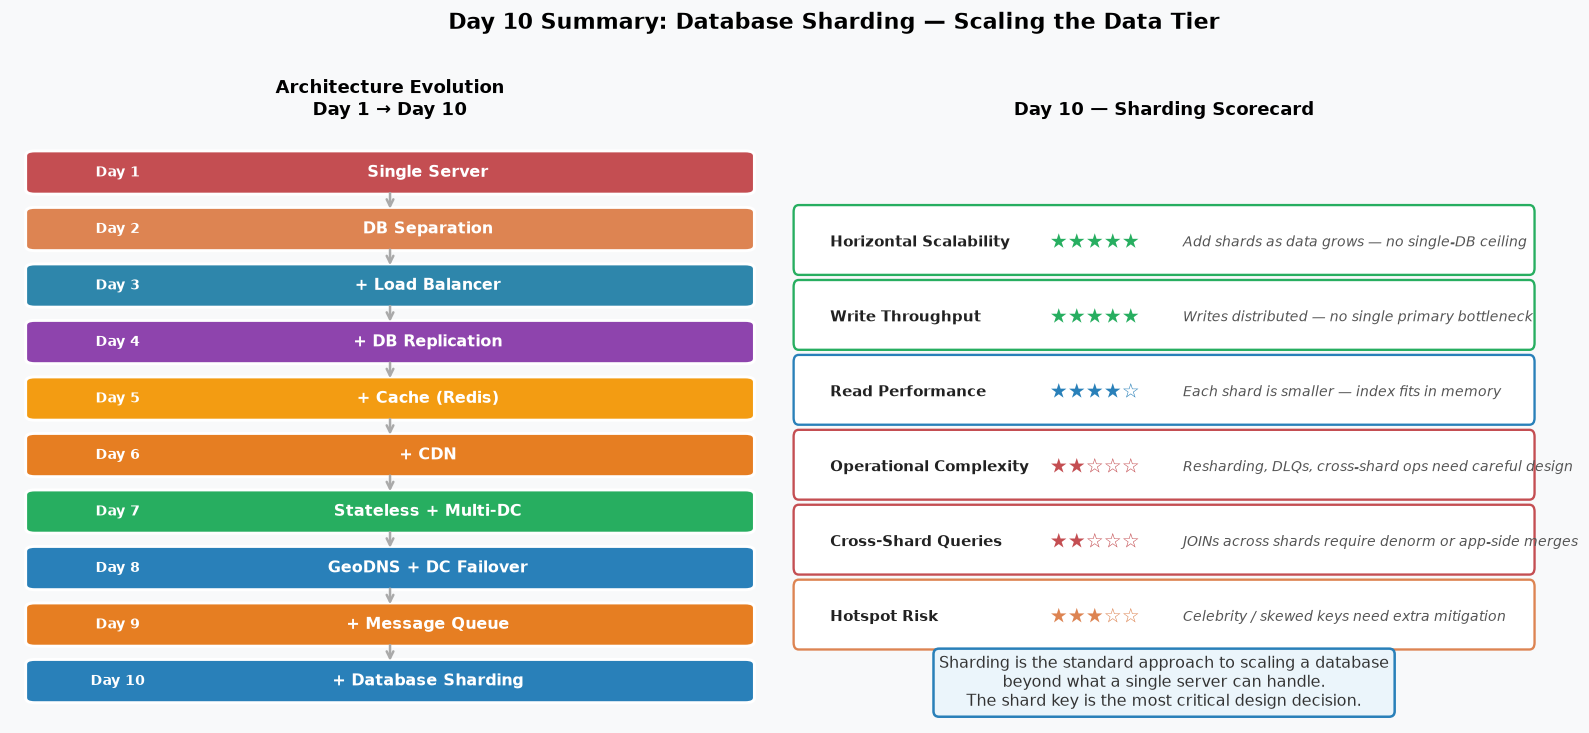

Day 10 complete.


In [8]:
# Day 10 scorecard + evolution Day 1 → 10

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 15)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 10', fontsize=11, fontweight='bold')

days = [
    ('Day 1',  'Single Server',                    '#C44E52'),
    ('Day 2',  'DB Separation',                    '#DD8452'),
    ('Day 3',  '+ Load Balancer',                  '#2E86AB'),
    ('Day 4',  '+ DB Replication',                 '#8E44AD'),
    ('Day 5',  '+ Cache (Redis)',                  '#F39C12'),
    ('Day 6',  '+ CDN',                            '#E67E22'),
    ('Day 7',  'Stateless + Multi-DC',             '#27AE60'),
    ('Day 8',  'GeoDNS + DC Failover',             '#2980B9'),
    ('Day 9',  '+ Message Queue',                  '#E67E22'),
    ('Day 10', '+ Database Sharding',              C_SHARD),
]
ys = np.linspace(13.8, 1.0, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.3, y - 0.42), 9.4, 0.85,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.4, y, day, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.43), xytext=(5, y - 0.43),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard ──────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 10 — Sharding Scorecard', fontsize=11, fontweight='bold')

metrics = [
    ('Horizontal Scalability', '★★★★★', C_OK,
     'Add shards as data grows — no single-DB ceiling'),
    ('Write Throughput',       '★★★★★', C_OK,
     'Writes distributed — no single primary bottleneck'),
    ('Read Performance',       '★★★★☆', C_SHARD,
     'Each shard is smaller — index fits in memory'),
    ('Operational Complexity', '★★☆☆☆', C_HOT,
     'Resharding, DLQs, cross-shard ops need careful design'),
    ('Cross-Shard Queries',    '★★☆☆☆', C_HOT,
     'JOINs across shards require denorm or app-side merges'),
    ('Hotspot Risk',           '★★★☆☆', C_ORANGE,
     'Celebrity / skewed keys need extra mitigation'),
]

y0 = 6.5
for (metric, stars, color, detail) in metrics:
    y0 -= 0.88
    r = FancyBboxPatch((0.2, y0 - 0.3), 11.6, 0.66,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4)
    ax.add_patch(r)
    ax.text(0.7,  y0, metric, ha='left',   va='center',
            fontsize=9,  fontweight='bold', color='#222')
    ax.text(4.9,  y0, stars,  ha='center', va='center',
            fontsize=12, color=color)
    ax.text(6.3,  y0, detail, ha='left',   va='center',
            fontsize=8.5, color='#555', fontstyle='italic')

ax.text(6, 0.45,
        'Sharding is the standard approach to scaling a database\n'
        'beyond what a single server can handle.\n'
        'The shard key is the most critical design decision.',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EBF5FB',
                  edgecolor=C_SHARD, lw=1.5))

plt.suptitle('Day 10 Summary: Database Sharding — Scaling the Data Tier',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day10_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 10 complete.")


### What this shows

**Left — Evolution Day 1 → Day 10:**  
Day 10 adds database sharding as the final horizontal scaling layer for the data tier. The full 10-day stack now covers: single server → DB separation → load balancer → DB replication → cache → CDN → stateless multi-DC → GeoDNS → message queue → sharding.

**Right — Day 10 Scorecard:**
- **Horizontal Scalability (5/5):** Add shards as data grows — no single-DB ceiling.
- **Write Throughput (5/5):** Writes distributed across shards — no single primary bottleneck.
- **Read Performance (4/5):** Each shard is smaller, so its index fits in RAM.
- **Operational Complexity (2/5):** Resharding, hotspot management, and cross-shard ops require careful planning and tooling.
- **Cross-Shard Queries (2/5):** JOINs and aggregations spanning shards require denorm or expensive application-side merges.
- **Hotspot Risk (3/5):** Celebrity and viral keys need additional mitigation layers beyond pure hash sharding.

**Key insight:** Sharding is the standard answer when you have outgrown a single database server, even after adding replication and caching. The shard key decision is made once and is extremely expensive to change — it must be chosen carefully at design time.